In [88]:
using PyPlot
using JLD2

### Define the system

In [89]:
Nx, Ny, Nz = [4, 4, 1]
N = Nx*Ny*Nz

λl = 1299.
θl = 30*π/180

θi = 0#π/2
φi = 0#1

Γ0 = 1.

Tstep, Tend = 1e-3, 1 # Normalised by Γ0
T = [0:Tstep:Tend;];

filename = "VarBext_MaxSlope_QC_Nx_$(Nx)_Ny_$(Ny)_Nz_$(Nz)_theta_$(round(θi, digits=1))_phi_$(φi)_thetal_$(round(θl, digits=2)).jld2"

@load filename var_Bext_max_diff_mean_σz sols;

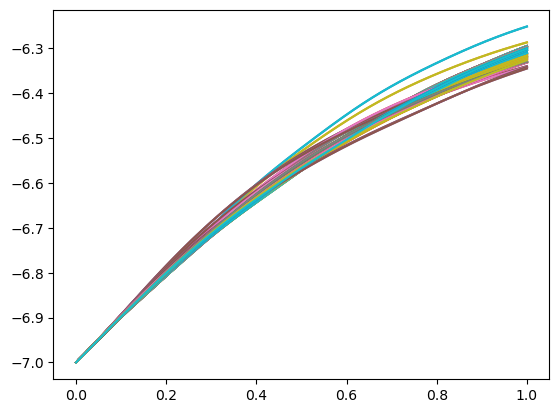

In [90]:
close("all")
figure()
for s in sols
    plot(T, s)
end
gcf()

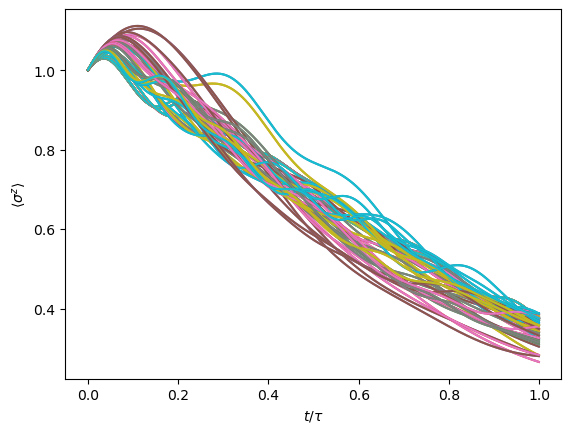

In [91]:
close("all")
figure()
for s in sols
    plot(T[1:end-1], diff(s)./Tstep)
end
savefig("AllDerivatives_Nx_$(Nx)_Ny_$(Ny)_Nz_$(Nz)_theta_$(round(θi, digits=2))_phi_$(φi)_thetal_$(round(θl, digits=2)).pdf")
xlabel(L"t/\tau")
ylabel(L"\langle \sigma^z\rangle")
pygui(false); gcf()
#pygui(true); show()

In [127]:
theta_Bext_array = range(0, pi/2, 10)*180/π
phi_Bext_array = range(0, pi/2, 10)*180/π;

In [128]:
mat_max_diff = reshape(var_Bext_max_diff_mean_σz, (length(phi_Bext_array), length(theta_Bext_array)));

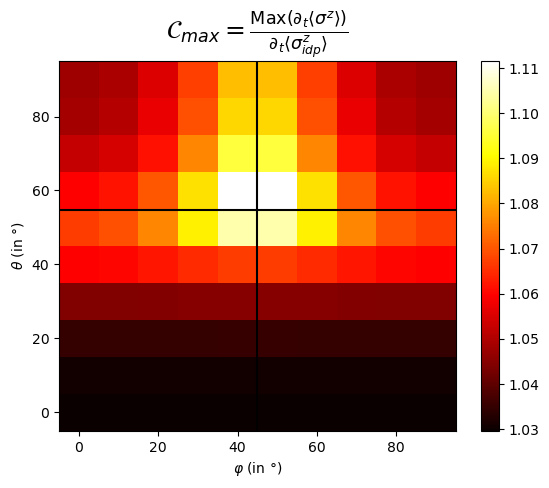

In [129]:
close("all")
fig, ax = plt.subplots()
c = pcolormesh(phi_Bext_array, theta_Bext_array, mat_max_diff', cmap="hot")
xlabel(L"$\varphi$ (in °)")
ylabel(L"$\theta$ (in °)")
fig.colorbar(c, ax=ax)
axhline(54.7, color="black")
axvline(45, color="black")
title(L"\mathcal{C}_{max}=\frac{\text{Max}(\partial_t \langle \sigma^z \rangle)}{\partial_t \langle \sigma^z_{idp} \rangle}", fontsize=18)
savefig("CmaxVaryBext_Nx_$(Nx)_Ny_$(Ny)_Nz_$(Nz)_theta_$(round(θi, digits=2))_phi_$(φi)_thetal_$(round(θl, digits=2)).pdf")
gcf()

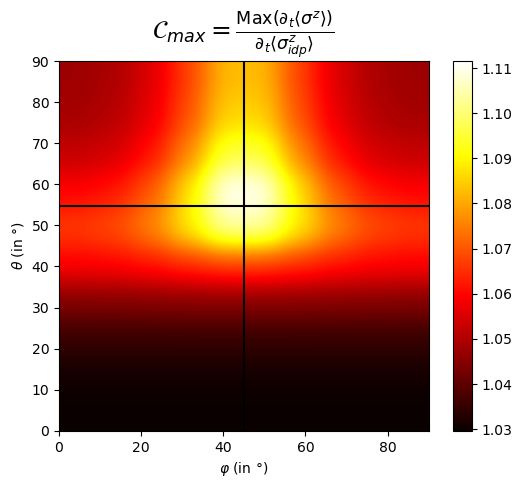

In [130]:
close("all")
fig, ax = plt.subplots()
c = imshow(mat_max_diff', cmap="hot", interpolation="gaussian", extent=(0, 90, 0, 90), aspect=1, origin="lower")
xlabel(L"$\varphi$ (in °)")
ylabel(L"$\theta$ (in °)")
colorbar(c, ax=ax)
axhline(54.7, color="black")
axvline(45, color="black")
title(L"\mathcal{C}_{max}=\frac{\text{Max}(\partial_t \langle \sigma^z \rangle)}{\partial_t \langle \sigma^z_{idp} \rangle}", fontsize=18)
savefig("SmoothedCmaxVaryBext_Nx_$(Nx)_Ny_$(Ny)_Nz_$(Nz)_theta_$(round(θi, digits=2))_phi_$(φi)_thetal_$(round(θl, digits=2)).pdf")
gcf()

# Yann's SR criterium 

In [152]:
diff_σz = [diff(s)/Tstep for s in sols]
max_diff_σz_Yann = maximum.([d for d in diff_σz]./(N*Γ0))
mat_max_diff_σz_Yann = reshape(max_diff_σz_Yann, (length(phi_Bext_array), length(theta_Bext_array)));

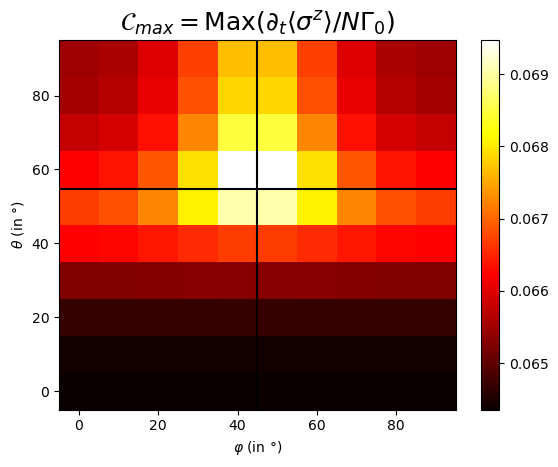

In [157]:
close("all")
fig, ax = plt.subplots()
c = pcolormesh(phi_Bext_array, theta_Bext_array, mat_max_diff_σz_Yann', cmap="hot")
xlabel(L"$\varphi$ (in °)")
ylabel(L"$\theta$ (in °)")
fig.colorbar(c, ax=ax)
axhline(54.7, color="black")
axvline(45, color="black")
#title(L"\mathcal{C}_{max}=\text{Max} ( \frac{\partial_t \langle \sigma^z \rangle}{N \Gamma_0} )", fontsize=18)
title(L"\mathcal{C}_{max}=\text{Max} (\partial_t \langle \sigma^z \rangle / N \Gamma_0 )", fontsize=18)
savefig("YannCmaxVaryBext_Nx_$(Nx)_Ny_$(Ny)_Nz_$(Nz)_theta_$(round(θi, digits=2))_phi_$(φi)_thetal_$(round(θl, digits=2)).pdf")
gcf()

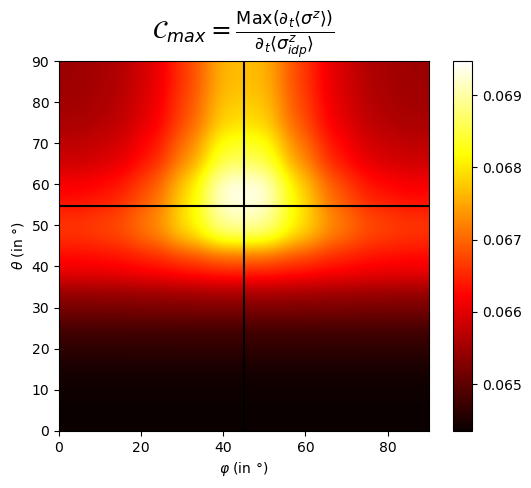

In [ ]:
close("all")
fig, ax = plt.subplots()
c = imshow(mat_max_diff_σz_Yann', cmap="hot", interpolation="gaussian", extent=(0, 90, 0, 90), aspect=1, origin="lower")
xlabel(L"$\varphi$ (in °)")
ylabel(L"$\theta$ (in °)")
colorbar(c, ax=ax)
axhline(54.7, color="black")
axvline(45, color="black")
title(L"\mathcal{C}_{max}=\text{Max} (\partial_t \langle \sigma^z \rangle / N \Gamma_0 )", fontsize=18)
savefig("YannSmoothedCmaxVaryBext_Nx_$(Nx)_Ny_$(Ny)_Nz_$(Nz)_theta_$(round(θi, digits=2))_phi_$(φi)_thetal_$(round(θl, digits=2)).pdf")
gcf()